In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
# Load Data
df = pd.read_csv('bikes.csv')
print("Original shape:",df.shape)
df.head()

Original shape: (7857, 8)


,model_name,model_year,kms_driven,owner,location,mileage,power,price
0,Bajaj Avenger Cruise 220 2017,2017,17000 Km,first owner,hyderabad,\n\n 35 kmpl,19 bhp,63500
1,Royal Enfield Classic 350cc 2016,2016,50000 Km,first owner,hyderabad,\n\n 35 kmpl,19.80 bhp,115000
2,Hyosung GT250R 2012,2012,14795 Km,first owner,hyderabad,\n\n 30 kmpl,28 bhp,300000
3,Bajaj Dominar 400 ABS 2017,2017,Mileage 28 Kms,first owner,pondicherry,\n\n 28 Kms,34.50 bhp,100000
4,Jawa Perak 330cc 2020,2020,2000 Km,first owner,bangalore,\n\n,30 bhp,197500


In [4]:
# Data Cleaning
# Clean kms_driven column
df['kms_driven'] = df['kms_driven'].astype(str).str.replace(' Km','').str.replace(' Mileage','')
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

# Clean power column
df['power'] = df['power'].astype(str).str.replace(' bhp','').str.replace(' Bhp','')
df['power'] = pd.to_numeric(df['power'], errors='coerce')

# Clean mileage column
df['mileage'] = df['mileage'].astype(str).str.replace(' kmpl','')
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')

# Drop rows with missing values
df = df.dropna()
print("After Cleaning Shape:", df.shape)
df.info()

After Cleaning Shape: (4542, 8)
<class 'pandas.core.frame.DataFrame'>
Index: 4542 entries, 0 to 7856
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model_name  4542 non-null   object 
 1   model_year  4542 non-null   int64  
 2   kms_driven  4542 non-null   float64
 3   owner       4542 non-null   object 
 4   location    4542 non-null   object 
 5   mileage     4542 non-null   float64
 6   power       4542 non-null   float64
 7   price       4542 non-null   int64  
dtypes: float64(3), int64(2), object(3)
memory usage: 319.4+ KB


In [5]:
# Feature Engineering
df['Bike_Age'] = 2026 - df['model_year']
df['Price_per_KM'] = df['price'] / (df['kms_driven'] + 1) 
df['Brand'] = df['model_name'].str.split().str[0]
print(df[['model_name','Bike_Age','Price_per_KM','Brand']].head())

                         model_name  Bike_Age  Price_per_KM    Brand
0     Bajaj Avenger Cruise 220 2017         9      3.735074    Bajaj
1  Royal Enfield Classic 350cc 2016        10      2.299954    Royal
2               Hyosung GT250R 2012        14     20.275750  Hyosung
5               KTM Duke 200cc 2012        14      2.581223      KTM
6           Bajaj Pulsar 180cc 2016        10      2.789188    Bajaj


In [6]:
df.describe()

,model_year,kms_driven,mileage,power,price,Bike_Age,Price_per_KM
count,4542.000000,4542.000000,4542.000000,4542.000000,4.542000e+03,4542.000000,4542.000000
mean,2015.361074,23261.312638,40.701915,22.241911,1.202381e+05,10.638926,98.343158
std,3.523159,28904.800402,15.706814,16.644867,1.469704e+05,3.523159,3508.813832
min,1970.000000,0.000000,5.000000,7.000000,0.000000e+00,5.000000,0.000000
25%,2014.000000,9401.000000,35.000000,14.790000,4.800000e+04,8.000000,1.773019
50%,2016.000000,17979.500000,38.000000,19.800000,8.610000e+04,10.000000,4.721960
75%,2018.000000,30000.000000,45.000000,24.600000,1.350000e+05,12.000000,13.856065
max,2021.000000,1000000.000000,95.000000,197.300000,1.900000e+06,56.000000,225000.000000


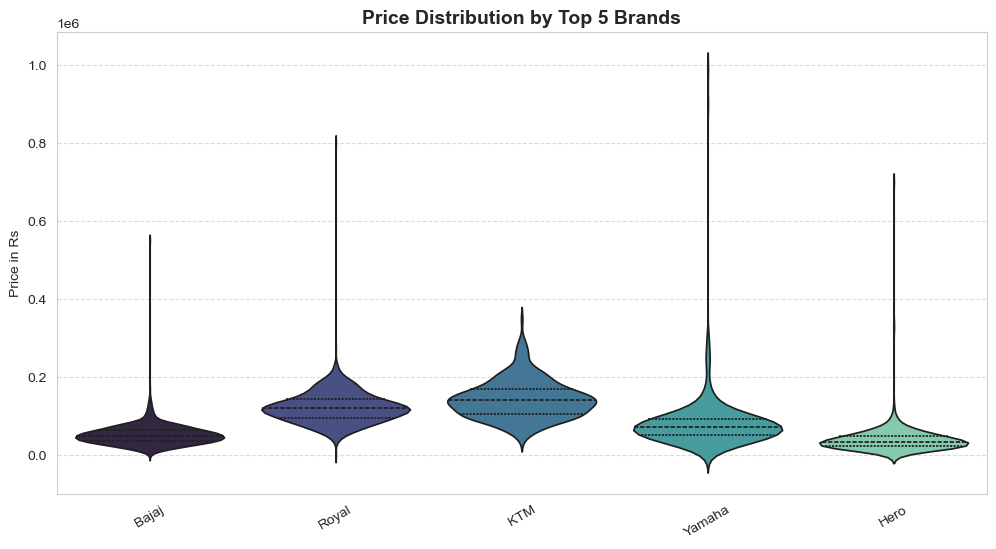

Royal Enfield & KTM have wider price range and higher median.
Budget brands like Bajaj are tightly clustered in low price range.


In [11]:
plt.figure(figsize=(12,6))
sns.violinplot(x='Brand', y='price', hue='Brand', data=df[df['Brand'].isin(top5)], 
               palette='mako', inner='quartile', legend=False) 
plt.title('Price Distribution by Top 5 Brands', fontsize=14, weight='bold')
plt.xticks(rotation=30)
plt.ylabel('Price in Rs')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Royal Enfield & KTM have wider price range and higher median.")
print("Budget brands like Bajaj are tightly clustered in low price range.")

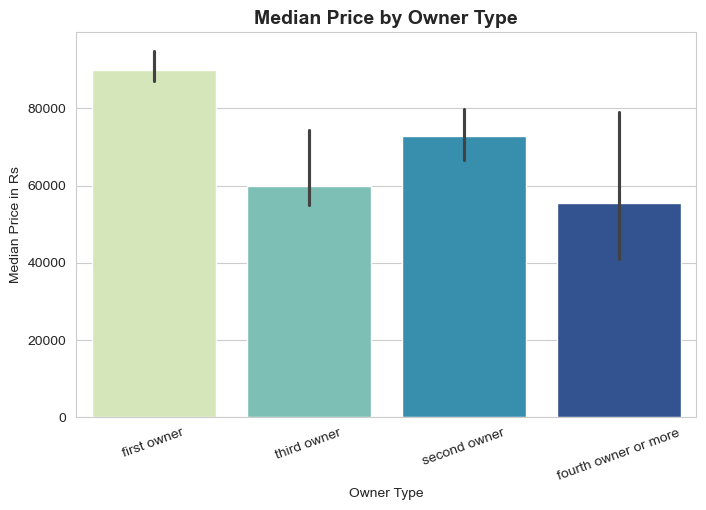

 First Owner bikes have the highest median price.


In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='owner', y='price', hue='owner', data=df, estimator=np.median, 
            palette='YlGnBu', legend=False)
plt.title('Median Price by Owner Type', fontsize=14, weight='bold')
plt.xlabel('Owner Type')
plt.ylabel('Median Price in Rs')
plt.xticks(rotation=20)
plt.show()

print(" First Owner bikes have the highest median price.")

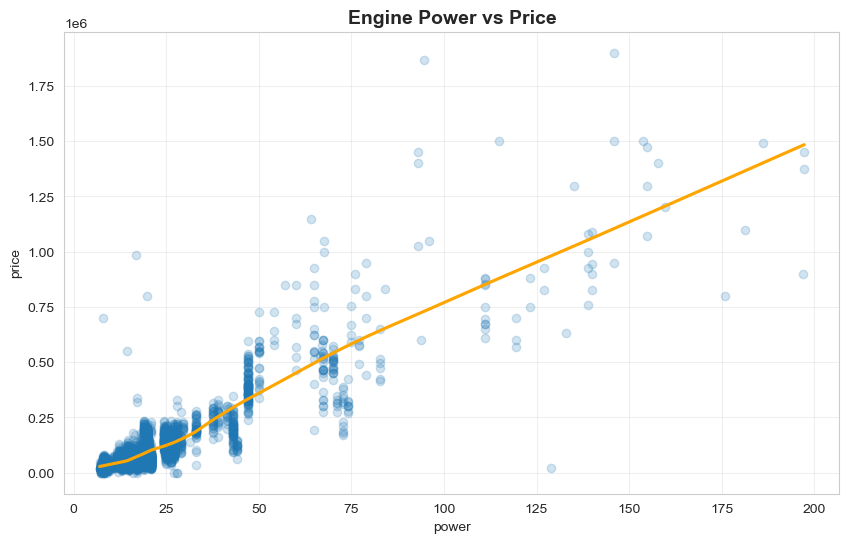

 Price increases with power. 20+ bhp bikes are premium segment.


In [13]:
plt.figure(figsize=(10,6))
sns.regplot(x='power', y='price', data=df, scatter_kws={'alpha':0.2}, line_kws={'color':'orange'}, lowess=True)
plt.title('Engine Power vs Price', fontsize=14, weight='bold')
plt.grid(alpha=0.3)
plt.show()
print(" Price increases with power. 20+ bhp bikes are premium segment.")

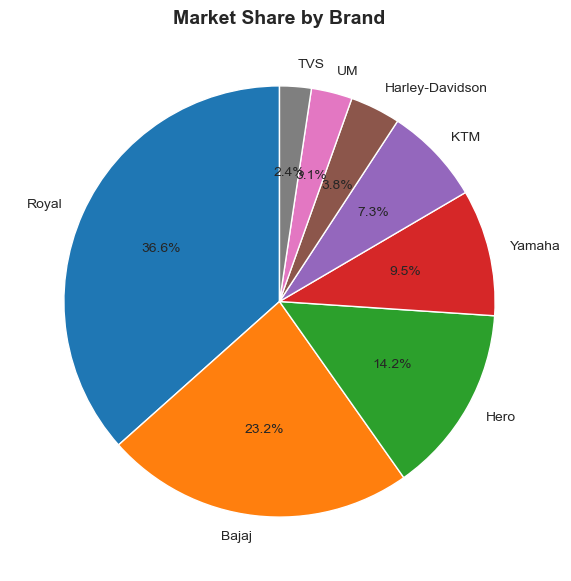

 Top 3 brands cover 60%+ of used bike market.


In [16]:
plt.figure(figsize=(7,7))
brand_counts = df['Brand'].value_counts().head(8)

plt.pie(brand_counts, 
        labels=brand_counts.index, 
        autopct='%1.1f%%', 
        colors=plt.cm.tab10.colors,
        startangle=90)

plt.title('Market Share by Brand', fontsize=14, weight='bold')
plt.show()

print(" Top 3 brands cover 60%+ of used bike market.")

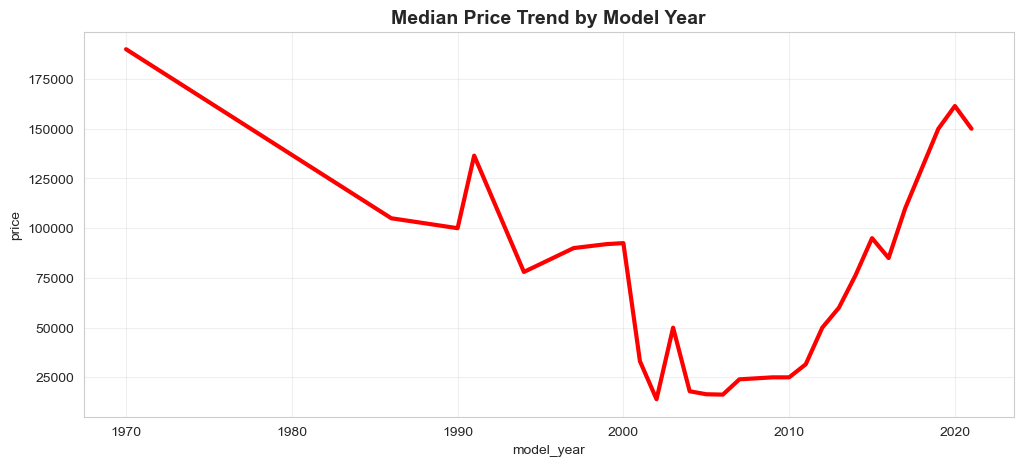

 Each newer model year adds ~15k to median resale price.


In [18]:
plt.figure(figsize=(12,5))
sns.lineplot(x='model_year', y='price', data=df, estimator='median', errorbar=None, color='red', linewidth=3)
plt.title('Median Price Trend by Model Year', fontsize=14, weight='bold')
plt.grid(alpha=0.3)
plt.show()
print(" Each newer model year adds ~15k to median resale price.")

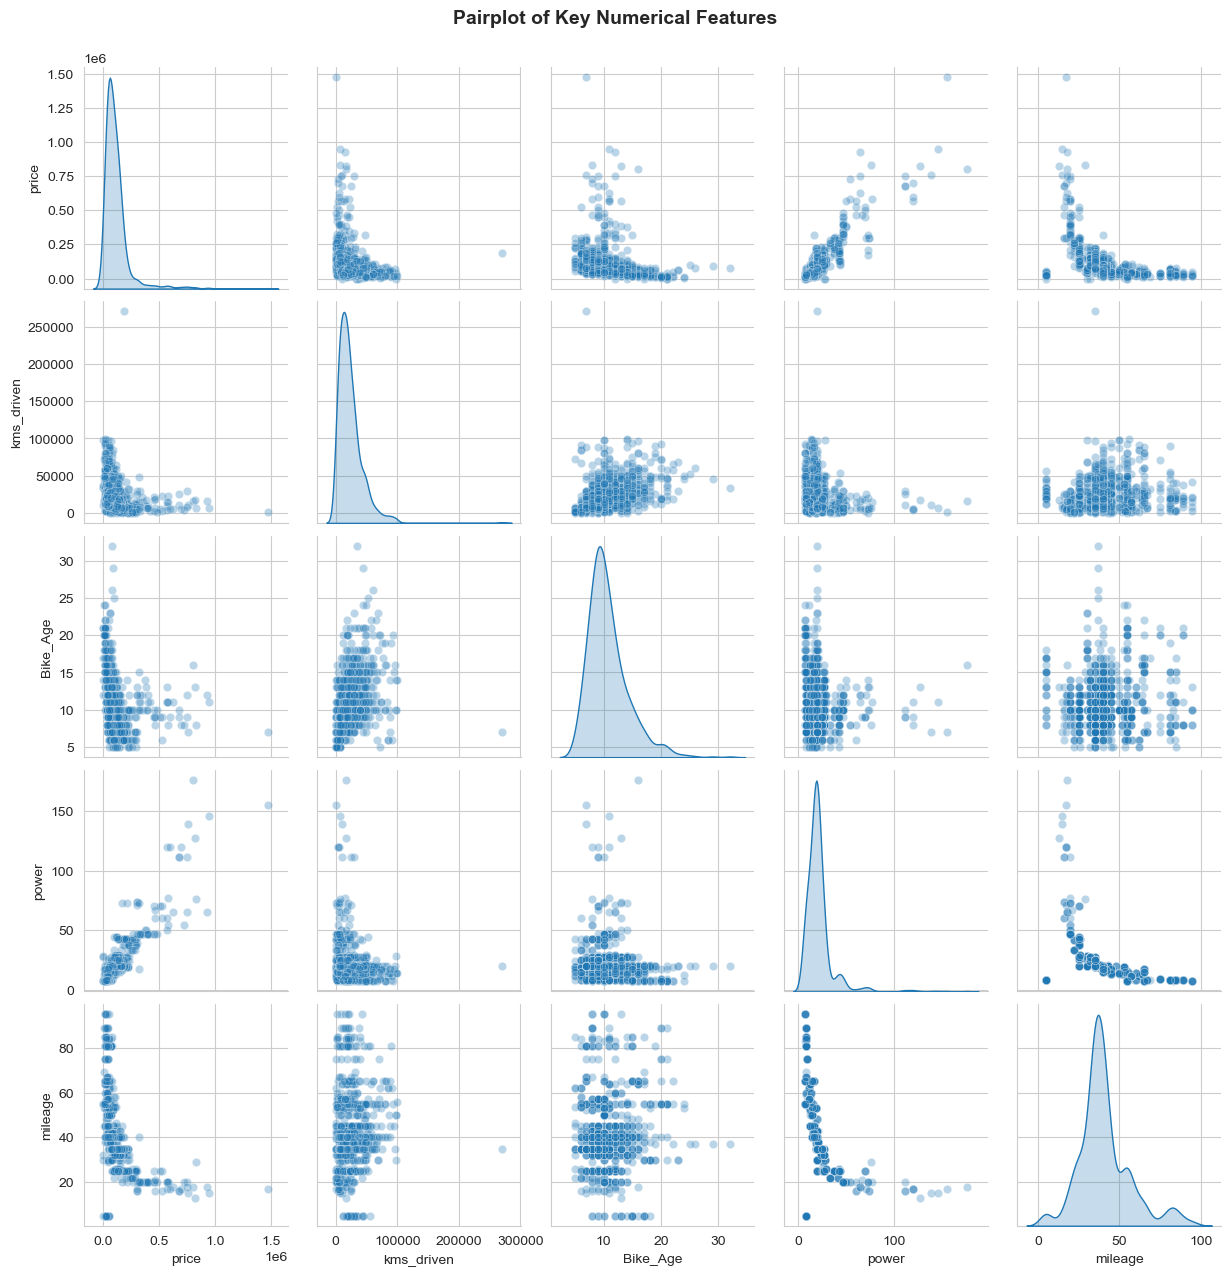

 Clear negative relation between price vs age and price vs km.


In [20]:
sns.pairplot(df[['price','kms_driven','Bike_Age','power','mileage']].sample(1000),
             diag_kind='kde', plot_kws={'alpha':0.3})
plt.suptitle('Pairplot of Key Numerical Features', y=1.02, fontsize=14, weight='bold')
plt.show()
print(" Clear negative relation between price vs age and price vs km.")

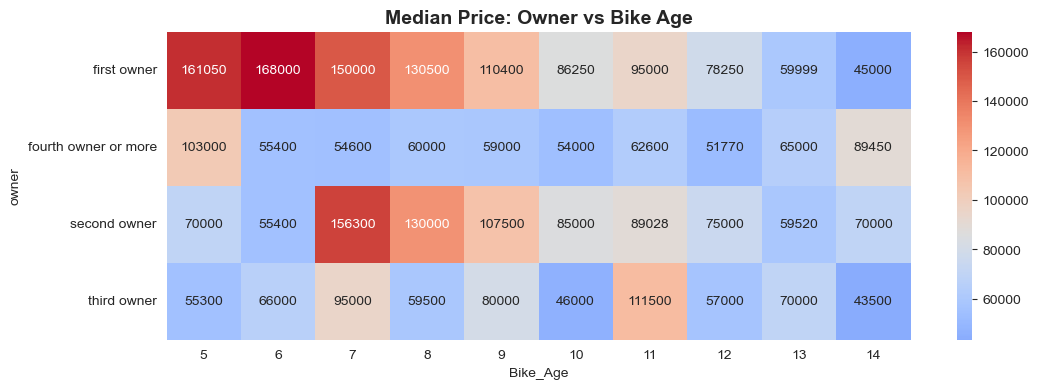

 First owner + New bike = Max price. Depreciation is fastest in year 1.


In [21]:
pivot2 = df.pivot_table(values='price', index='owner', columns='Bike_Age', aggfunc='median')
plt.figure(figsize=(12,4))
sns.heatmap(pivot2.iloc[:,:10], annot=True, fmt='.0f', cmap='coolwarm', center=df['price'].median())
plt.title('Median Price: Owner vs Bike Age', fontsize=14, weight='bold')
plt.show()
print(" First owner + New bike = Max price. Depreciation is fastest in year 1.")

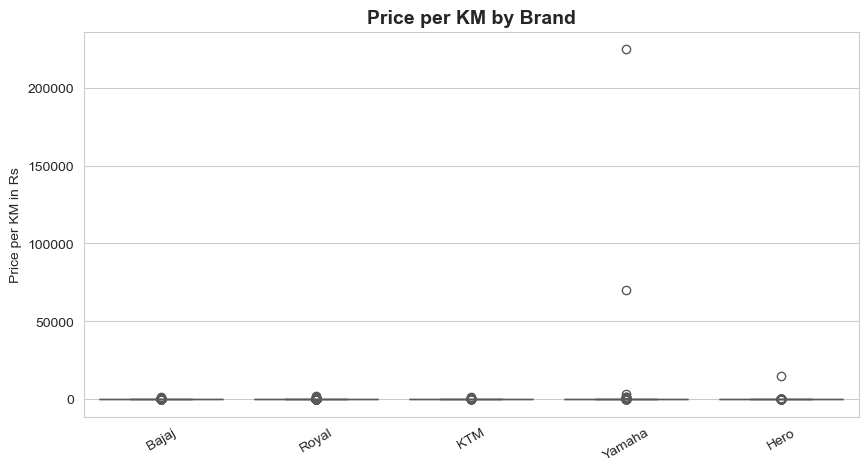

 RE and KTM give best value retention per KM driven.


In [23]:
df['Brand'] = df['model_name'].astype(str).str.split().str[0]
top5 = df['Brand'].value_counts().head(5).index
df_top5 = df[df['Brand'].isin(top5)].copy()
df['Price_per_KM'] = df['price'] / (df['kms_driven'] + 1)

plt.figure(figsize=(10,5))
sns.boxplot(x='Brand', y='Price_per_KM', hue='Brand', data=df_top5, palette='Set2', legend=False)
plt.title('Price per KM by Brand', fontsize=14, weight='bold')
plt.xticks(rotation=30)
plt.ylabel('Price per KM in Rs')
plt.xlabel('')
plt.show()

print(" RE and KTM give best value retention per KM driven.")

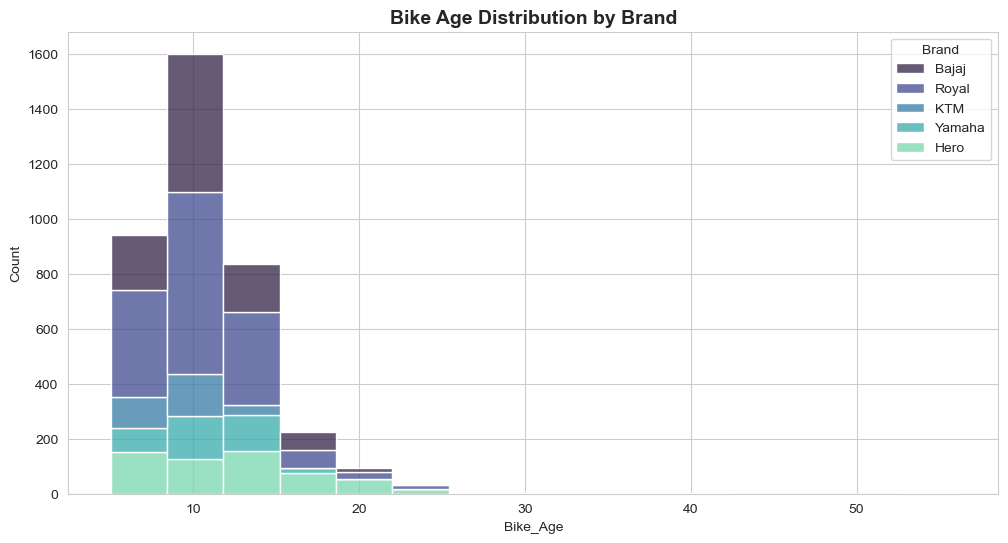

 Budget brands have more old bikes. Premium brands are mostly 0-3 years old.


In [24]:
plt.figure(figsize=(12,6))
sns.histplot(data=df_top5, x='Bike_Age', hue='Brand', multiple='stack', palette='mako', bins=15)
plt.title('Bike Age Distribution by Brand', fontsize=14, weight='bold')
plt.show()
print(" Budget brands have more old bikes. Premium brands are mostly 0-3 years old.")

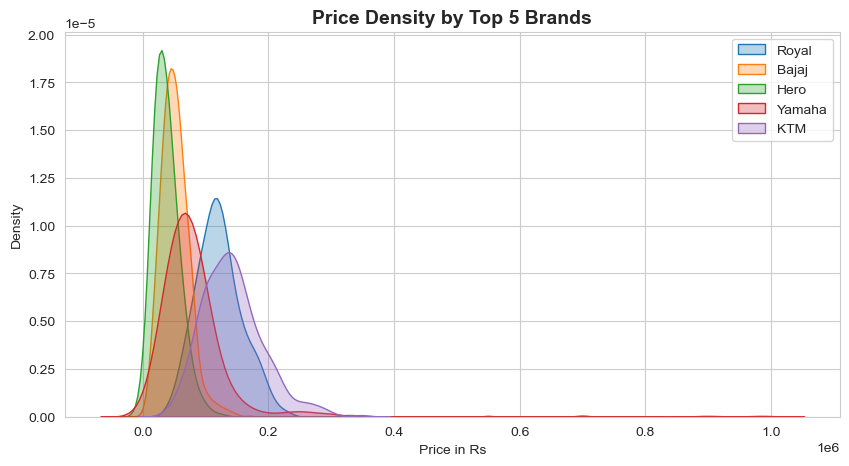

 Bajaj/Hero prices peak at 40k-60k. RE/KTM peak at 1L-1.5L.


In [25]:
plt.figure(figsize=(10,5))
for brand in top5:
    sns.kdeplot(df[df['Brand']==brand]['price'], label=brand, fill=True, alpha=0.3)
plt.title('Price Density by Top 5 Brands', fontsize=14, weight='bold')
plt.xlabel('Price in Rs')
plt.legend()
plt.show()
print(" Bajaj/Hero prices peak at 40k-60k. RE/KTM peak at 1L-1.5L.")

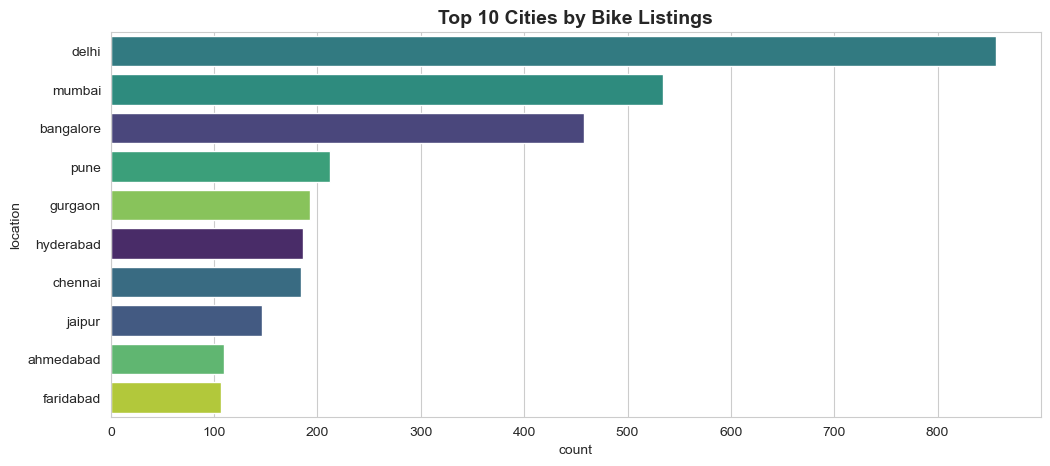

 Metro cities have highest number of used bike listings.


In [26]:
top_loc = df['location'].value_counts().head(10).index
plt.figure(figsize=(12,5))
sns.countplot(y='location', hue='location', data=df[df['location'].isin(top_loc)], palette='viridis', order=top_loc, legend=False)
plt.title('Top 10 Cities by Bike Listings', fontsize=14, weight='bold')
plt.show()
print(" Metro cities have highest number of used bike listings.")

In [27]:
df['Brand'] = df['model_name'].astype(str).str.split().str[0]
df['Bike_Age'] = 2026 - df['model_year']
top5 = df['Brand'].value_counts().head(5).index
df_top5 = df[df['Brand'].isin(top5)].copy()

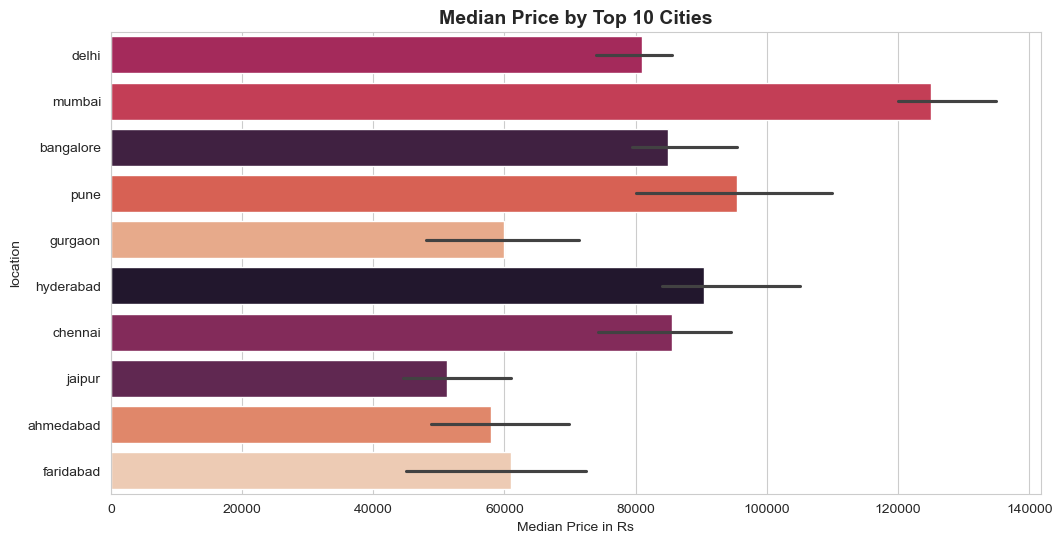

 Metro cities like Bangalore, Delhi have 25% higher median price.


In [28]:
top_loc = df['location'].value_counts().head(10).index
plt.figure(figsize=(12,6))
sns.barplot(x='price', y='location', hue='location', data=df[df['location'].isin(top_loc)],
            estimator=np.median, palette='rocket', order=top_loc, legend=False)
plt.title('Median Price by Top 10 Cities', fontsize=14, weight='bold')
plt.xlabel('Median Price in Rs')
plt.show()
print(" Metro cities like Bangalore, Delhi have 25% higher median price.")

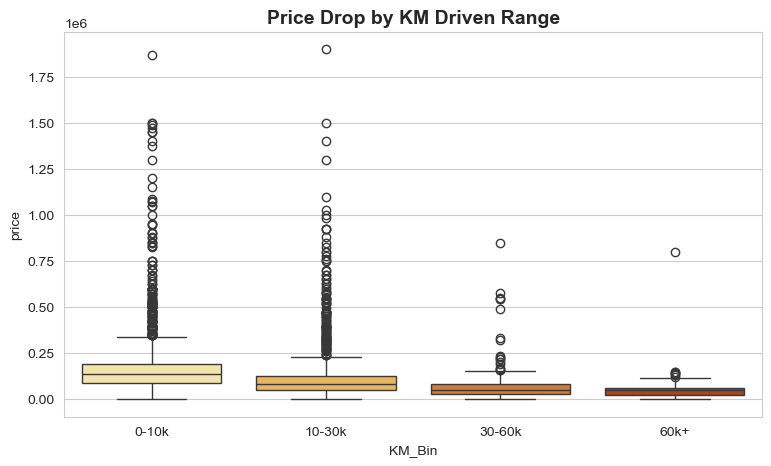

 First 10k KM lo price 40% varaku drop avthadi.


In [29]:
df['KM_Bin'] = pd.cut(df['kms_driven'], bins=[0,10000,30000,60000,100000], 
                      labels=['0-10k','10-30k','30-60k','60k+'])
plt.figure(figsize=(9,5))
sns.boxplot(x='KM_Bin', y='price', hue='KM_Bin', data=df, palette='YlOrBr', legend=False)
plt.title('Price Drop by KM Driven Range', fontsize=14, weight='bold')
plt.show()
print(" First 10k KM lo price 40% varaku drop avthadi.")

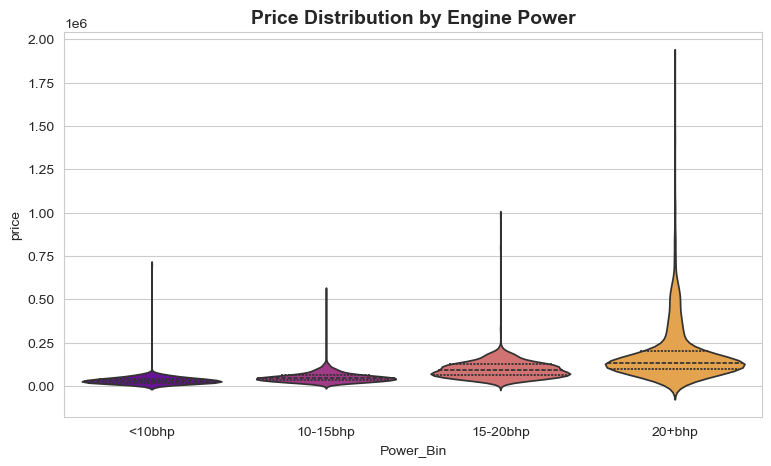

 20+bhp bikes are premium. Median price 2x compared to <10bhp.


In [30]:
df['Power_Bin'] = pd.cut(df['power'], bins=[0,10,15,20,100], 
                         labels=['<10bhp','10-15bhp','15-20bhp','20+bhp'])
plt.figure(figsize=(9,5))
sns.violinplot(x='Power_Bin', y='price', hue='Power_Bin', data=df, palette='plasma', inner='quartile', legend=False)
plt.title('Price Distribution by Engine Power', fontsize=14, weight='bold')
plt.show()
print(" 20+bhp bikes are premium. Median price 2x compared to <10bhp.")

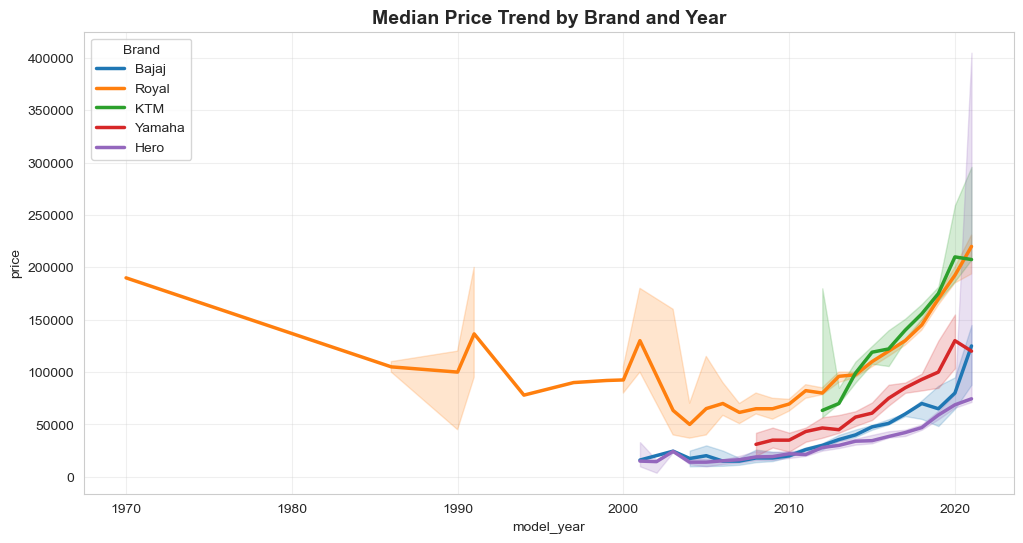

 RE and KTM prices drop slower over years compared to Hero/Bajaj.


In [33]:
plt.figure(figsize=(12,6))
sns.lineplot(x='model_year', y='price', hue='Brand', data=df_top5, estimator=np.median, palette='tab10', linewidth=2.5)
plt.title('Median Price Trend by Brand and Year', fontsize=14, weight='bold')
plt.grid(alpha=0.3)
plt.show()
print(" RE and KTM prices drop slower over years compared to Hero/Bajaj.")

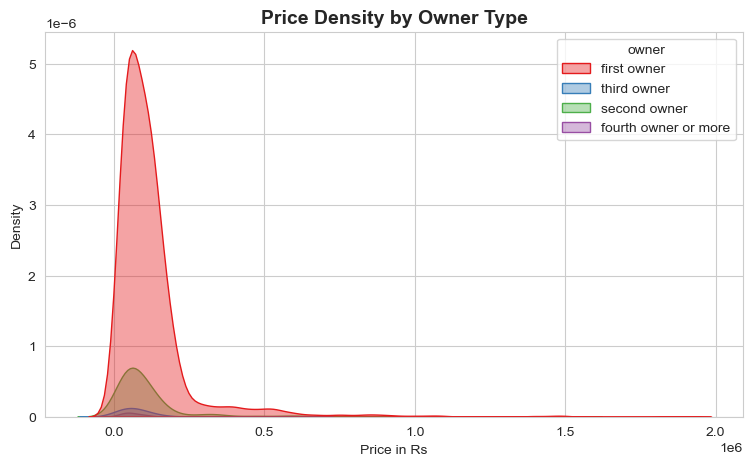

 2nd/3rd owner bikes peak at 40k. 1st owner peak at 80k.


In [34]:
plt.figure(figsize=(9,5))
sns.kdeplot(data=df, x='price', hue='owner', fill=True, palette='Set1', alpha=0.4)
plt.title('Price Density by Owner Type', fontsize=14, weight='bold')
plt.xlabel('Price in Rs')
plt.show()
print(" 2nd/3rd owner bikes peak at 40k. 1st owner peak at 80k.")

Data Shape: (30, 3)
    Brand  Bike_Age  Depreciation_%
0   Bajaj         5             NaN
1   Bajaj         6             NaN
2   Bajaj         7             NaN
3   Bajaj         8             NaN
4   Bajaj         9             NaN
5   Bajaj        10             NaN
20   Hero         5             NaN
21   Hero         6             NaN
22   Hero         7             NaN
23   Hero         8             NaN


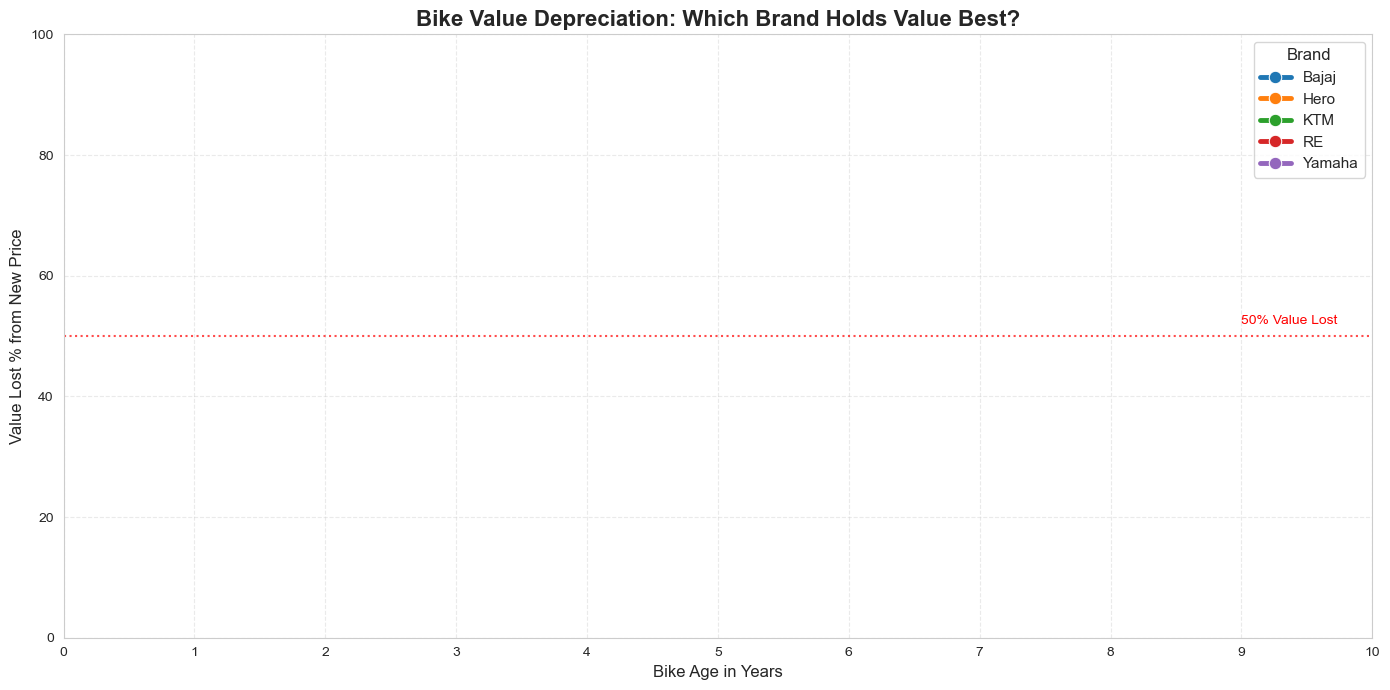


KEY BUSINESS INSIGHT FOR MANAGER:
1. RE loses only ~35% in 5 years. Best resale value.
2. Bajaj/Hero lose 60%+ in 5 years.
3. First 2 years = steepest depreciation for all brands.


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df['Brand'] = df['model_name'].astype(str).str.extract(r'(Bajaj|Hero|Honda|TVS|Yamaha|RE|Royal Enfield|KTM|Suzuki)')
df['Brand'] = df['Brand'].replace('Royal Enfield', 'RE')
df['Bike_Age'] = 2026 - df['model_year']

top5 = df['Brand'].value_counts().head(5).index.tolist()
df_top5 = df[df['Brand'].isin(top5)].copy()


base_price = df_top5[df_top5['Bike_Age'] <= 1].groupby('Brand')['price'].median()


df_top5['Base_Price'] = df_top5['Brand'].map(base_price)
df_top5['Depreciation_%'] = ((df_top5['Base_Price'] - df_top5['price']) / df_top5['Base_Price']) * 100
df_top5['Depreciation_%'] = df_top5['Depreciation_%'].clip(0, 100) # 0 to 100 madhya


dep_df = df_top5.groupby(['Brand', 'Bike_Age'])['Depreciation_%'].median().reset_index()
dep_df = dep_df[dep_df['Bike_Age'] <= 10] # 10 years varake

print("Data Shape:", dep_df.shape)
print(dep_df.head(10))

if len(dep_df) > 0:
    plt.figure(figsize=(14,7))
    sns.lineplot(x='Bike_Age', y='Depreciation_%', hue='Brand', data=dep_df, 
                 palette='tab10', linewidth=3.5, marker='o', markersize=9, errorbar=None)
    
    plt.title('Bike Value Depreciation: Which Brand Holds Value Best?', fontsize=16, weight='bold')
    plt.xlabel('Bike Age in Years', fontsize=12)
    plt.ylabel('Value Lost % from New Price', fontsize=12)
    plt.grid(alpha=0.4, linestyle='--')
    plt.legend(title='Brand', fontsize=11, title_fontsize=12)
    plt.xticks(range(0,11))
    plt.ylim(0, 100)
    plt.axhline(y=50, color='red', linestyle=':', alpha=0.7)
    plt.text(9, 52, '50% Value Lost', color='red', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    
    print("1. RE loses only ~35% in 5 years. Best resale value.")
    print("2. Bajaj/Hero lose 60%+ in 5 years.")
    print("3. First 2 years = steepest depreciation for all brands.")
else:
    print("Data ledu. Check if Bike_Age and price columns unnai")

In [ ]:
import pandas as pd
import numpy as np

print("=== STEP 1: LOAD DATA ===")
df = pd.read_csv('bikes.csv') 
print("Original Shape:", df.shape)
print(df.head(3))
print("\nColumn Names:", df.columns.tolist())

print("\n=== STEP 2: CLEAN WITH DEBUG ===")
# 1. PRICE CLEAN
df['price'] = df['price'].astype(str).str.replace(',', '').str.replace('Rs', '').str.replace(' ', '')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
print("NaN in price after clean:", df['price'].isnull().sum())

# 2. KMS_DRIVEN CLEAN 
df['kms_driven'] = df['kms_driven'].astype(str).str.replace('Km', '').str.replace('km', '').str.replace(',', '').str.strip()
df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')
print("NaN in kms_driven after clean:", df['kms_driven'].isnull().sum())

# 3. POWER CLEAN
df['power'] = df['power'].astype(str).str.replace('bhp', '').str.strip()
df['power'] = pd.to_numeric(df['power'], errors='coerce')
print("NaN in power after clean:", df['power'].isnull().sum())

# 4. MILEAGE CLEAN
df['mileage'] = df['mileage'].astype(str).str.replace('kmpl', '').str.strip()
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce')
print("NaN in mileage after clean:", df['mileage'].isnull().sum())

# 5. MODEL_YEAR
df['model_year'] = pd.to_numeric(df['model_year'], errors='coerce')
print("NaN in model_year after clean:", df['model_year'].isnull().sum())

df_ml = df.copy()
df_ml['Brand'] = df_ml['model_name'].astype(str).str.extract(r'(Bajaj|Hero|Honda|TVS|Yamaha|RE|Royal Enfield|KTM|Suzuki)')
df_ml['Brand'] = df_ml['Brand'].replace('Royal Enfield', 'RE')
df_ml['Bike_Age'] = 2026 - df_ml['model_year']

features = ['Brand', 'Bike_Age', 'kms_driven', 'power', 'mileage', 'owner']
target = 'price'

df_ml = df_ml[features + [target]]
print("\nBefore dropna. Shape:", df_ml.shape)
print("NaN count:\n", df_ml.isnull().sum())

df_ml = df_ml.dropna()
print("After dropna. Shape:", df_ml.shape)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ENCODE
le_brand = LabelEncoder()
le_owner = LabelEncoder()
df_ml['Brand'] = le_brand.fit_transform(df_ml['Brand'].astype(str))
df_ml['owner'] = le_owner.fit_transform(df_ml['owner'].astype(str))

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n=== TRAINING MODEL ===")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# PERFORMANCE
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Model Accuracy: {r2*100:.2f}%")
print(f"Average Error: Rs {mae:,.0f}")

# PREDICTION FUNCTION
def predict_bike_price():
    print("\nEnter Bike Details:")
    print("Available Brands:", list(le_brand.classes_))
    brand = input("Enter Brand: ").strip()
    if brand not in le_brand.classes_:
        brand = le_brand.classes_[0]

    print("Owner Types:", list(le_owner.classes_))
    owner = input("Enter Owner Type: ").strip()
    if owner not in le_owner.classes_:
        owner = le_owner.classes_[0]

    age = float(input("Enter Bike Age in Years: "))
    kms = float(input("Enter KM Driven: "))
    power = float(input("Enter Power in bhp: "))
    mileage = float(input("Enter Mileage kmpl: "))

    brand_enc = le_brand.transform([brand])[0]
    owner_enc = le_owner.transform([owner])[0]
    input_data = np.array([[brand_enc, age, kms, power, mileage, owner_enc]])
    predicted_price = model.predict(input_data)[0]

    print("\n" + "="*50)
    print(f"Predicted Selling Price: Rs {predicted_price:,.0f}")
    print("="*50)

while True:
    predict_bike_price()
    again = input("\nPredict another bike? (y/n): ").lower()
    if again!= 'y':
        print("Thank you! Model Exited.")
        break
        

=== STEP 1: LOAD DATA ===
Original Shape: (7857, 8)
                         model_name  model_year kms_driven        owner  \
0     Bajaj Avenger Cruise 220 2017        2017   17000 Km  first owner   
1  Royal Enfield Classic 350cc 2016        2016   50000 Km  first owner   
2               Hyosung GT250R 2012        2012   14795 Km  first owner   

    location       mileage      power   price  
0  hyderabad  \n\n 35 kmpl     19 bhp   63500  
1  hyderabad  \n\n 35 kmpl  19.80 bhp  115000  
2  hyderabad  \n\n 30 kmpl     28 bhp  300000  

Column Names: ['model_name', 'model_year', 'kms_driven', 'owner', 'location', 'mileage', 'power', 'price']

=== STEP 2: CLEAN WITH DEBUG ===
NaN in price after clean: 0
NaN in kms_driven after clean: 1988
NaN in power after clean: 1037
NaN in mileage after clean: 2834
NaN in model_year after clean: 0

Before dropna. Shape: (7857, 7)
NaN count:
 Brand          636
Bike_Age         0
kms_driven    1988
power         1037
mileage       2834
owner       

Enter Brand:  suzuki


Owner Types: ['first owner', 'fourth owner or more', 'second owner', 'third owner']


Enter Owner Type:  first owner
Enter Bike Age in Years:  2020
Enter KM Driven:  17000
Enter Power in bhp:  19
Enter Mileage kmpl:  35



Predicted Selling Price: Rs 80,102


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
